# Netflix Titles Analysis: Trends and Content Comparison

**Problem Statement:**

1. **How has the number of titles added to Netflix changed over time (by year)?**
2. **Do Movies and TV Shows differ in typical duration (minutes vs. seasons) or in ratings distribution?**


## Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Data Loading and Data Dictionary

In `netflix_titles.csv` dataset key columns include:

- **show_id**: Unique identifier for each title
- **type**: Movie or TV Show
- **title**: Name of the title
- **director**: Director of the title
- **cast**: Main cast members
- **country**: Country of production
- **date_added**: Date the title was added to Netflix
- **release_year**: Year the title was released
- **rating**: Rating (e.g., TV-MA, PG, etc.)
- **duration**: Duration (minutes for movies, seasons for TV shows)
- **listed_in**: Genre(s)
- **description**: Short description of the title

In [38]:
# Load the dataset
df = pd.read_csv('netflix_titles.csv')

# Display first few rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Cleaning

In [39]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nDataset shape:", df.shape)

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Dataset shape: (8807, 12)


In [40]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [41]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Check data types
print(df.dtypes)

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object


## extract_year function

This function extracts the year from a datetime object, returning NaN if the date is null.

In [ ]:
def extract_year(date):
    """
    Extracts the year from a datetime object and returns 
    year if date is valid, NaN otherwise
    """
    if pd.isnull(date):
        return np.nan
    return date.year

# Applying the function to create year_added column
df['year_added'] = df['date_added'].apply(extract_year)

# printing the unique years and missing values
print("Unique years added:", sorted(df['year_added'].dropna().unique()))
print(f"\nMissing year_added values: {df['year_added'].isnull().sum()}")

Unique years added: [np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0)]

Missing year_added values: 98


## Analysis 1: Trend Over Time - Titles Added Per Year

We examine how the number of titles added to Netflix has changed over time.

In [43]:
# Group by year_added and count titles
titles_per_year = df.dropna(subset=['year_added']).groupby('year_added').size().reset_index(name='count')
titles_per_year = titles_per_year.sort_values('year_added')

print("Titles added per year:")
print(titles_per_year)

Titles added per year:
    year_added  count
0       2008.0      2
1       2009.0      2
2       2010.0      1
3       2011.0     13
4       2012.0      3
5       2013.0     10
6       2014.0     23
7       2015.0     73
8       2016.0    418
9       2017.0   1164
10      2018.0   1625
11      2019.0   1999
12      2020.0   1878
13      2021.0   1498


### Visualization 1: Line Chart of Titles Added Over Time

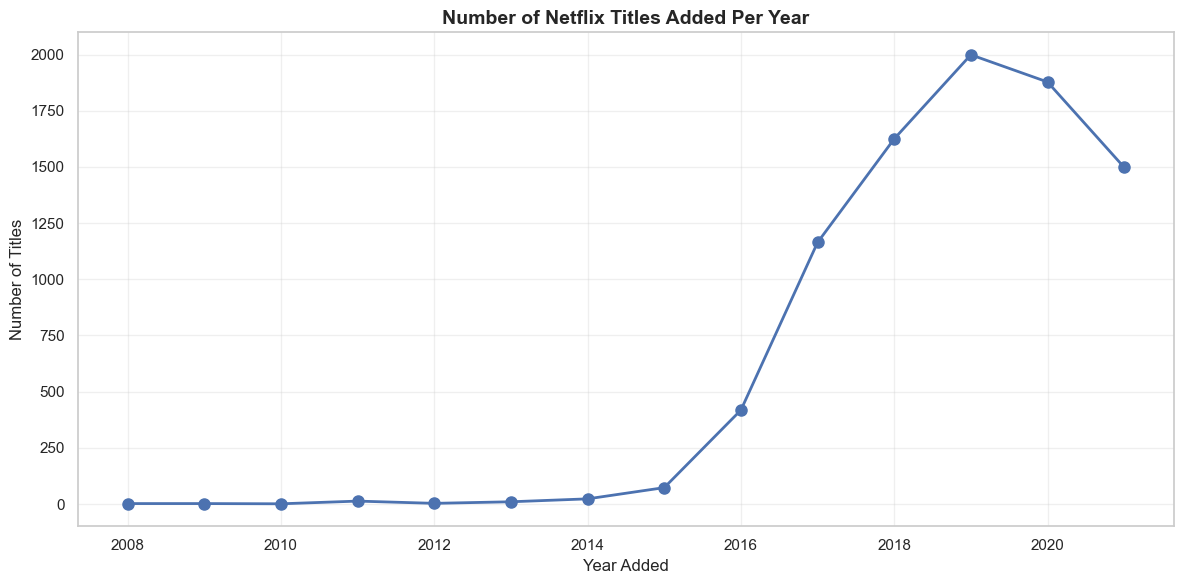

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(titles_per_year['year_added'], titles_per_year['count'], marker='o', linewidth=2, markersize=8)
plt.title('Number of Netflix Titles Added Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**

The line chart reveals a dramatic growth in Netflix's content additions over time. Starting with minimal additions in 2008-2014, there was explosive growth from 2015 onwards, peaking at nearly 2000 titles in 2019. After 2019, we observe a decline through 2021. This pattern likely reflects Netflix's aggressive content expansion strategy during its global growth phase when most of the people were at home consuming a lot more content, but is seeming to decline after its peak.

## Analysis 2: Comparison of Movies vs TV Shows

### Part A: Grouped Summary - Content Type Distribution

In [45]:
# Count by type
type_counts = df['type'].value_counts()
print("Content type distribution:")
print(type_counts)
print(f"\nPercentage breakdown:")
print(df['type'].value_counts(normalize=True) * 100)

Content type distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Percentage breakdown:
type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64


### Visualization 2: Bar Chart of Content Types

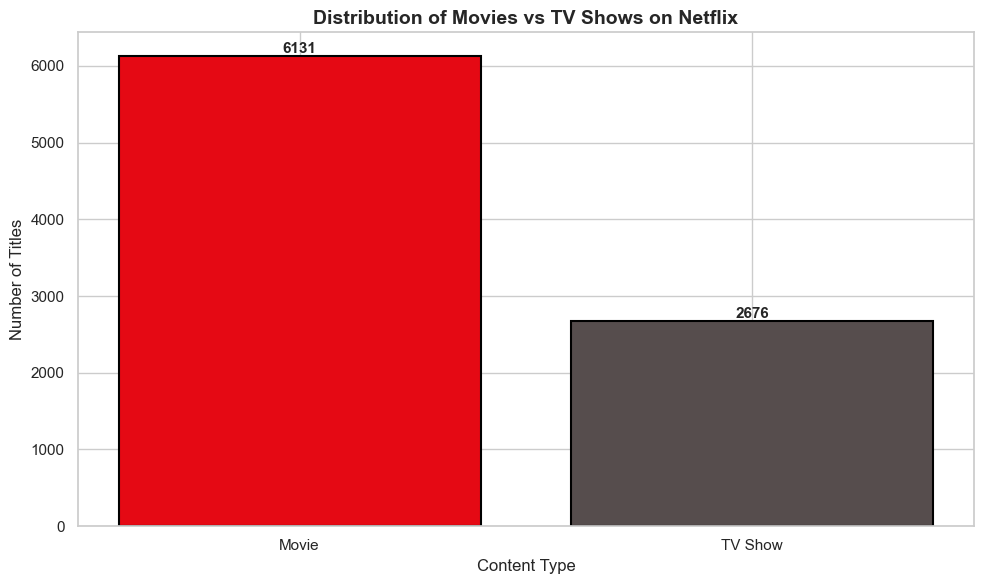

In [46]:
plt.figure(figsize=(10, 6))
colors = ['#E50914', '#564d4d']  # Netflix red and dark gray
bars = plt.bar(type_counts.index, type_counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Distribution of Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:**

Netflix's catalog is heavily dominated by movies, which comprise approximately 70% of all content. TV shows make up the remaining 30%. This distribution suggests Netflix's strategy has historically focused more on acquiring or producing movies, though TV shows represent a significant and growing portion of their offerings.

### Part B: Ratings Distribution Comparison

In [47]:
# Get top ratings for each type
movies_ratings = df[df['type'] == 'Movie']['rating'].value_counts().head(10)
tv_ratings = df[df['type'] == 'TV Show']['rating'].value_counts().head(10)

print("Top 10 Movie Ratings:")
print(movies_ratings)
print("\nTop 10 TV Show Ratings:")
print(tv_ratings)

Top 10 Movie Ratings:
rating
TV-MA    2062
TV-14    1427
R         797
TV-PG     540
PG-13     490
PG        287
TV-Y7     139
TV-Y      131
TV-G      126
NR         75
Name: count, dtype: int64

Top 10 TV Show Ratings:
rating
TV-MA       1145
TV-14        733
TV-PG        323
TV-Y7        195
TV-Y         176
TV-G          94
NR             5
R              2
TV-Y7-FV       1
Name: count, dtype: int64


## Summary and Conclusions

This analysis of the Netflix titles dataset revealed several key insights:

1. **Growth Trend**: Netflix experienced explosive content growth from 2015-2019, adding nearly 2000 titles at its peak in 2019, followed by a decline through 2021.

2. **Content Mix**: Movies dominate the catalog (~70%), but TV shows represent a substantial portion (~30%) of offerings.

3. **Target Audience**: Both movies and TV shows heavily target mature audiences (TV-MA, R ratings), with TV shows being more concentrated in this demographic.

4. **Duration Patterns**: Movies follow standard feature film lengths (90-100 minutes median), while most TV shows are 1-season productions, suggesting a mix of limited series and shows that didn't continue beyond their first season.

These findings provide valuable insights into Netflix's content strategy and the evolution of their streaming catalog.